In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# SYMBOLS FOR HYDRO PART ONLY
# ---------------------------------------------------------------------
r = sp.Symbol('r')
u = sp.Symbol('u')
cs = sp.Symbol('cs')
gamma = sp.Symbol('gamma')
lam = sp.Symbol('lam')
v = sp.Symbol('v')
s = sp.Symbol('s')

# ---------------------------------------------------------------------
# Define symbolic A(r) and f(r) only for HYDRO, reused for sonic cs
# ---------------------------------------------------------------------
A_sym = 1/r + 1/(r**2 - 2*r) + 0.5 * (3*r**2 - lam**2)/(r**3 - (r - 2)*lam**2)

f_sym = -(lam**2/r**3) * ((1-3/r)/(1 - lam**2*(1-2/r)/r**2))+ 1/(r**2 - 2*r)


print("\n================ HYDRODYNAMIC SECTION ================")

# ---------------------------------------------------------------------
# s(v) expression i.e. dc_s/dr
# ---------------------------------------------------------------------

s_expr = - ((gamma-1)/(gamma+1))*(
        (1/u + u/(1-u**2))*v + A_sym) / (cs/(gamma - 1 - cs**2) + 1/cs)

# ---------------------------------------------------------------------
# Build N' and D'
# ---------------------------------------------------------------------
A_r  = sp.diff(A_sym, r)
f_r  = sp.diff(f_sym, r)

# Numerator and Denominator of du/dr
Num = - (1/cs + cs/(gamma - (1 + cs**2))) * f_sym + ((gamma-1)/(gamma+1)) * (2*cs/(gamma - (1 + cs**2))) * A_sym
Nprime = sp.diff(sp.diff(Num, r),r)  
Denom = (1/cs + cs/(gamma - (1 + cs**2))) * (u/(1 - u**2)) - ((gamma-1)/(gamma+1)) * (2*cs/(gamma - (1 + cs**2))) * (1/u + u/(1-u**2))
Dprime = sp.diff(sp.diff(Denom, r),r)         

# replace du/dr -> v   and   dcs/dr -> s
Nprime = Nprime.subs({sp.diff(cs, r): s})
Dprime = Dprime.subs({sp.diff(u, r): v, sp.diff(cs, r): s})

# Quadratic: v*D' - N' = 0
eq = sp.simplify(v*Dprime - Nprime)

# substitute s(v) before collecting
eq = sp.simplify(eq.subs(s, s_expr))
poly = sp.expand(eq)

# terms of the quadratic
terms = sp.collect(poly, v, evaluate=False)
a = sp.simplify(terms.get(v**2, 0))
b = sp.simplify(terms.get(v, 0))
c = sp.simplify(terms.get(1, 0))

print("\nSymbolic quadratic coefficients:")
print("\na ="); print(a)
print("\nb ="); print(b)
print("\nc ="); print(c)

# ---------------------------------------------------------------------
# Lambdify N, D, and s_expr
# ---------------------------------------------------------------------
Num_func = sp.lambdify(
    (r, u, cs, gamma, lam),
    Num,
    'numpy'
)

Denom_func = sp.lambdify(
    (r, u, cs, gamma, lam),
    Denom,
    'numpy'
)

s_func = sp.lambdify(
    (r, u, cs, gamma, lam, v),
    s_expr,
    'numpy'
)




================ HYDRODYNAMIC SECTION ================

Symbolic quadratic coefficients:

a =
cs*(-cs**2 + gamma - 1)/(u*(gamma*u**2 - gamma + u**2 - 1))

b =
cs*(-1.5*cs**2*lam**2*r**2 + 4.0*cs**2*lam**2*r - 2.0*cs**2*lam**2 + 2.5*cs**2*r**4 - 4.0*cs**2*r**3 + 1.5*gamma*lam**2*r**2 - 4.0*gamma*lam**2*r + 2.0*gamma*lam**2 - 2.5*gamma*r**4 + 4.0*gamma*r**3 - 1.5*lam**2*r**2 + 4.0*lam**2*r - 2.0*lam**2 + 2.5*r**4 - 4.0*r**3)/(r*(-1.0*gamma*lam**2*r**2 + 4.0*gamma*lam**2*r - 4.0*gamma*lam**2 + 1.0*gamma*r**4 - 2.0*gamma*r**3 - 1.0*lam**2*r**2 + 4.0*lam**2*r - 4.0*lam**2 + 1.0*r**4 - 2.0*r**3))

c =
(-6.0*cs**2*gamma*lam**6*r**6 + 48.0*cs**2*gamma*lam**6*r**5 - 168.0*cs**2*gamma*lam**6*r**4 + 352.0*cs**2*gamma*lam**6*r**3 - 480.0*cs**2*gamma*lam**6*r**2 + 384.0*cs**2*gamma*lam**6*r - 128.0*cs**2*gamma*lam**6 + 18.0*cs**2*gamma*lam**4*r**8 - 108.0*cs**2*gamma*lam**4*r**7 + 288.0*cs**2*gamma*lam**4*r**6 - 528.0*cs**2*gamma*lam**4*r**5 + 672.0*cs**2*gamma*lam**4*r**4 - 384.0*cs**2*gamma*lam*

In [2]:

def E_sonic_numeric(R, lam_val, gamma_val):
    """
    Sonic energy as function of r 
    """
    f = -(lam_val**2/R**3)*(1-(3/R))/(1 - (1-(2/R))*(lam_val/R)**2)  \
         + 1/(R**2 - 2*R)
    A = (1/R) + 1/(R**2 - 2*R) + 0.5*(3*R**2 - lam_val**2)/(R**3 - (lam_val**2)*(R-2))
    
    if f <= 0 or A <= 0:
        return np.nan

    cs2 = f*(gamma_val+1)/(2*A)
    if cs2 <= 0 or cs2 >= 1:
        return np.nan
    
    factor = (gamma_val - 1)/(gamma_val - 1 - cs2)
    
    denom = (1-cs2)*(1-(1-2/R)*lam_val**2/R**2)
    if denom <= 0:
        return np.nan
    
    inside = (1-2/R)/denom
    if inside <= 0:
        return np.nan

    return factor * np.sqrt(inside)
def cs_sonic_numeric(R, lam_val, gamma_val):
    """
    Sonic sound speed using f/A definition consistent with E_sonic_numeric.
    """
    f = -(lam_val**2/R**3)*(1-(3/R))/(1 - (1-(2/R))*(lam_val/R)**2)  \
         + 1/(R**2 - 2*R)
    A = (1/R) + 1/(R**2 - 2*R) + 0.5*(3*R**2 - lam_val**2)/(R**3 - (lam_val**2)*(R-2))
    
    if f <= 0 or A <= 0:
        return np.nan

    cs2 = f*(gamma_val+1)/(2*A)
    if cs2 <= 0 or cs2 >= 1:
        return np.nan
    
    return np.sqrt(cs2)

def u_sonic_numeric(R, lam_val, gamma_val):
    """
    Compute the velocity u at the sonic point using f/A.
    """
    f = -(lam_val**2/R**3)*(1-(3/R))/(1 - (1-(2/R))*(lam_val/R)**2)  \
         + 1/(R**2 - 2*R)
    A = (1/R) + 1/(R**2 - 2*R) + 0.5*(3*R**2 - lam_val**2)/(R**3 - (lam_val**2)*(R-2))
    
    if f <= 0 or A <= 0:
        return np.nan

    u2 = f/A
    if u2 <= 0 or u2 >= 1:
        return np.nan
    
    return np.sqrt(u2)
# ---------------------------------------------------------------------
# Simple Newton-Raphson for a 1D scalar function
# ---------------------------------------------------------------------
def newton_root(F, x0, tol=1e-10, maxiter=50):
    x = x0
    for _ in range(maxiter):
        fx = F(x)
        if not np.isfinite(fx):
            return np.nan
        h = 1e-5*max(1.0, abs(x))
        dfx = (F(x + h) - F(x - h))/(2*h)
        if not np.isfinite(dfx) or dfx == 0:
            return np.nan
        x_new = x - fx/dfx
        if not np.isfinite(x_new):
            return np.nan
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return np.nan

def a_num(cs, u, lam, r, gamma):
    return cs*(-cs**2 + gamma - 1)/(u*(gamma*u**2 - gamma + u**2 - 1))
def b_num(cs, u, lam, r, gamma):
    return cs*(-1.5*cs**2*lam**2*r**2 + 4.0*cs**2*lam**2*r - 2.0*cs**2*lam**2 + 2.5*cs**2*r**4 - 4.0*cs**2*r**3 + 1.5*gamma*lam**2*r**2 - 4.0*gamma*lam**2*r + 2.0*gamma*lam**2 - 2.5*gamma*r**4 + 4.0*gamma*r**3 - 1.5*lam**2*r**2 + 4.0*lam**2*r - 2.0*lam**2 + 2.5*r**4 - 4.0*r**3)/(r*(-1.0*gamma*lam**2*r**2 + 4.0*gamma*lam**2*r - 4.0*gamma*lam**2 + 1.0*gamma*r**4 - 2.0*gamma*r**3 - 1.0*lam**2*r**2 + 4.0*lam**2*r - 4.0*lam**2 + 1.0*r**4 - 2.0*r**3))

def c_num(cs, u, lam, r, gamma):
    return (-6.0*cs**2*gamma*lam**6*r**6 + 48.0*cs**2*gamma*lam**6*r**5 - 168.0*cs**2*gamma*lam**6*r**4 + 352.0*cs**2*gamma*lam**6*r**3 - 480.0*cs**2*gamma*lam**6*r**2 + 384.0*cs**2*gamma*lam**6*r - 128.0*cs**2*gamma*lam**6 + 18.0*cs**2*gamma*lam**4*r**8 - 108.0*cs**2*gamma*lam**4*r**7 + 288.0*cs**2*gamma*lam**4*r**6 - 528.0*cs**2*gamma*lam**4*r**5 + 672.0*cs**2*gamma*lam**4*r**4 - 384.0*cs**2*gamma*lam**4*r**3 - 6.0*cs**2*gamma*lam**2*r**10 - 60.0*cs**2*gamma*lam**2*r**9 + 432.0*cs**2*gamma*lam**2*r**8 - 864.0*cs**2*gamma*lam**2*r**7 + 576.0*cs**2*gamma*lam**2*r**6 + 10.0*cs**2*gamma*r**12 - 48.0*cs**2*gamma*r**11 + 96.0*cs**2*gamma*r**10 - 64.0*cs**2*gamma*r**9 + 6.0*cs**2*lam**6*r**6 - 48.0*cs**2*lam**6*r**5 + 168.0*cs**2*lam**6*r**4 - 352.0*cs**2*lam**6*r**3 + 480.0*cs**2*lam**6*r**2 - 384.0*cs**2*lam**6*r + 128.0*cs**2*lam**6 - 18.0*cs**2*lam**4*r**8 + 108.0*cs**2*lam**4*r**7 - 288.0*cs**2*lam**4*r**6 + 528.0*cs**2*lam**4*r**5 - 672.0*cs**2*lam**4*r**4 + 384.0*cs**2*lam**4*r**3 + 6.0*cs**2*lam**2*r**10 + 60.0*cs**2*lam**2*r**9 - 432.0*cs**2*lam**2*r**8 + 864.0*cs**2*lam**2*r**7 - 576.0*cs**2*lam**2*r**6 - 10.0*cs**2*r**12 + 48.0*cs**2*r**11 - 96.0*cs**2*r**10 + 64.0*cs**2*r**9 + 2.0*gamma**2*lam**6*r**6 - 24.0*gamma**2*lam**6*r**5 + 120.0*gamma**2*lam**6*r**4 - 320.0*gamma**2*lam**6*r**3 + 480.0*gamma**2*lam**6*r**2 - 384.0*gamma**2*lam**6*r + 128.0*gamma**2*lam**6 - 6.0*gamma**2*lam**4*r**8 + 60.0*gamma**2*lam**4*r**7 - 240.0*gamma**2*lam**4*r**6 + 456.0*gamma**2*lam**4*r**5 - 384.0*gamma**2*lam**4*r**4 + 96.0*gamma**2*lam**4*r**3 + 12.0*gamma**2*lam**2*r**10 - 114.0*gamma**2*lam**2*r**9 + 432.0*gamma**2*lam**2*r**8 - 720.0*gamma**2*lam**2*r**7 + 432.0*gamma**2*lam**2*r**6 - 6.0*gamma**2*r**11 + 12.0*gamma**2*r**10 - 8.0*gamma**2*r**9 - 2.0*lam**6*r**6 + 24.0*lam**6*r**5 - 120.0*lam**6*r**4 + 320.0*lam**6*r**3 - 480.0*lam**6*r**2 + 384.0*lam**6*r - 128.0*lam**6 + 6.0*lam**4*r**8 - 60.0*lam**4*r**7 + 240.0*lam**4*r**6 - 456.0*lam**4*r**5 + 384.0*lam**4*r**4 - 96.0*lam**4*r**3 - 12.0*lam**2*r**10 + 114.0*lam**2*r**9 - 432.0*lam**2*r**8 + 720.0*lam**2*r**7 - 432.0*lam**2*r**6 + 6.0*r**11 - 12.0*r**10 + 8.0*r**9)/(cs*r**3*(-1.0*cs**2*gamma*lam**6*r**6 + 12.0*cs**2*gamma*lam**6*r**5 - 60.0*cs**2*gamma*lam**6*r**4 + 160.0*cs**2*gamma*lam**6*r**3 - 240.0*cs**2*gamma*lam**6*r**2 + 192.0*cs**2*gamma*lam**6*r - 64.0*cs**2*gamma*lam**6 + 3.0*cs**2*gamma*lam**4*r**8 - 30.0*cs**2*gamma*lam**4*r**7 + 120.0*cs**2*gamma*lam**4*r**6 - 240.0*cs**2*gamma*lam**4*r**5 + 240.0*cs**2*gamma*lam**4*r**4 - 96.0*cs**2*gamma*lam**4*r**3 - 3.0*cs**2*gamma*lam**2*r**10 + 24.0*cs**2*gamma*lam**2*r**9 - 72.0*cs**2*gamma*lam**2*r**8 + 96.0*cs**2*gamma*lam**2*r**7 - 48.0*cs**2*gamma*lam**2*r**6 + 1.0*cs**2*gamma*r**12 - 6.0*cs**2*gamma*r**11 + 12.0*cs**2*gamma*r**10 - 8.0*cs**2*gamma*r**9 - 1.0*cs**2*lam**6*r**6 + 12.0*cs**2*lam**6*r**5 - 60.0*cs**2*lam**6*r**4 + 160.0*cs**2*lam**6*r**3 - 240.0*cs**2*lam**6*r**2 + 192.0*cs**2*lam**6*r - 64.0*cs**2*lam**6 + 3.0*cs**2*lam**4*r**8 - 30.0*cs**2*lam**4*r**7 + 120.0*cs**2*lam**4*r**6 - 240.0*cs**2*lam**4*r**5 + 240.0*cs**2*lam**4*r**4 - 96.0*cs**2*lam**4*r**3 - 3.0*cs**2*lam**2*r**10 + 24.0*cs**2*lam**2*r**9 - 72.0*cs**2*lam**2*r**8 + 96.0*cs**2*lam**2*r**7 - 48.0*cs**2*lam**2*r**6 + 1.0*cs**2*r**12 - 6.0*cs**2*r**11 + 12.0*cs**2*r**10 - 8.0*cs**2*r**9 + 1.0*gamma**2*lam**6*r**6 - 12.0*gamma**2*lam**6*r**5 + 60.0*gamma**2*lam**6*r**4 - 160.0*gamma**2*lam**6*r**3 + 240.0*gamma**2*lam**6*r**2 - 192.0*gamma**2*lam**6*r + 64.0*gamma**2*lam**6 - 3.0*gamma**2*lam**4*r**8 + 30.0*gamma**2*lam**4*r**7 - 120.0*gamma**2*lam**4*r**6 + 240.0*gamma**2*lam**4*r**5 - 240.0*gamma**2*lam**4*r**4 + 96.0*gamma**2*lam**4*r**3 + 3.0*gamma**2*lam**2*r**10 - 24.0*gamma**2*lam**2*r**9 + 72.0*gamma**2*lam**2*r**8 - 96.0*gamma**2*lam**2*r**7 + 48.0*gamma**2*lam**2*r**6 - 1.0*gamma**2*r**12 + 6.0*gamma**2*r**11 - 12.0*gamma**2*r**10 + 8.0*gamma**2*r**9 - 1.0*lam**6*r**6 + 12.0*lam**6*r**5 - 60.0*lam**6*r**4 + 160.0*lam**6*r**3 - 240.0*lam**6*r**2 + 192.0*lam**6*r - 64.0*lam**6 + 3.0*lam**4*r**8 - 30.0*lam**4*r**7 + 120.0*lam**4*r**6 - 240.0*lam**4*r**5 + 240.0*lam**4*r**4 - 96.0*lam**4*r**3 - 3.0*lam**2*r**10 + 24.0*lam**2*r**9 - 72.0*lam**2*r**8 + 96.0*lam**2*r**7 - 48.0*lam**2*r**6 + 1.0*r**12 - 6.0*r**11 + 12.0*r**10 - 8.0*r**9))
# =====================================================================


# O-type  solution (only outer sonic point exist)


================ ENERGY (NUMERIC ONLY) ================

Sonic radii found: [19.859491541421754]
a,b,c = -0.14571902582498442 -0.0027072226662023116 0.00022048845553508344
ROOTS: -0.04928163474425029 0.03070326002018498
-------------------------------------------------------------------------------------------------------------------------
Sonic point 1: r = 19.859491541421754  |  u_sonic = 0.1475421649080365  |  cs_sonic = 0.15936375214178602

du/dr_critical 1: -0.04928163474425029

du/dr_critical 2: 0.03070326002018498



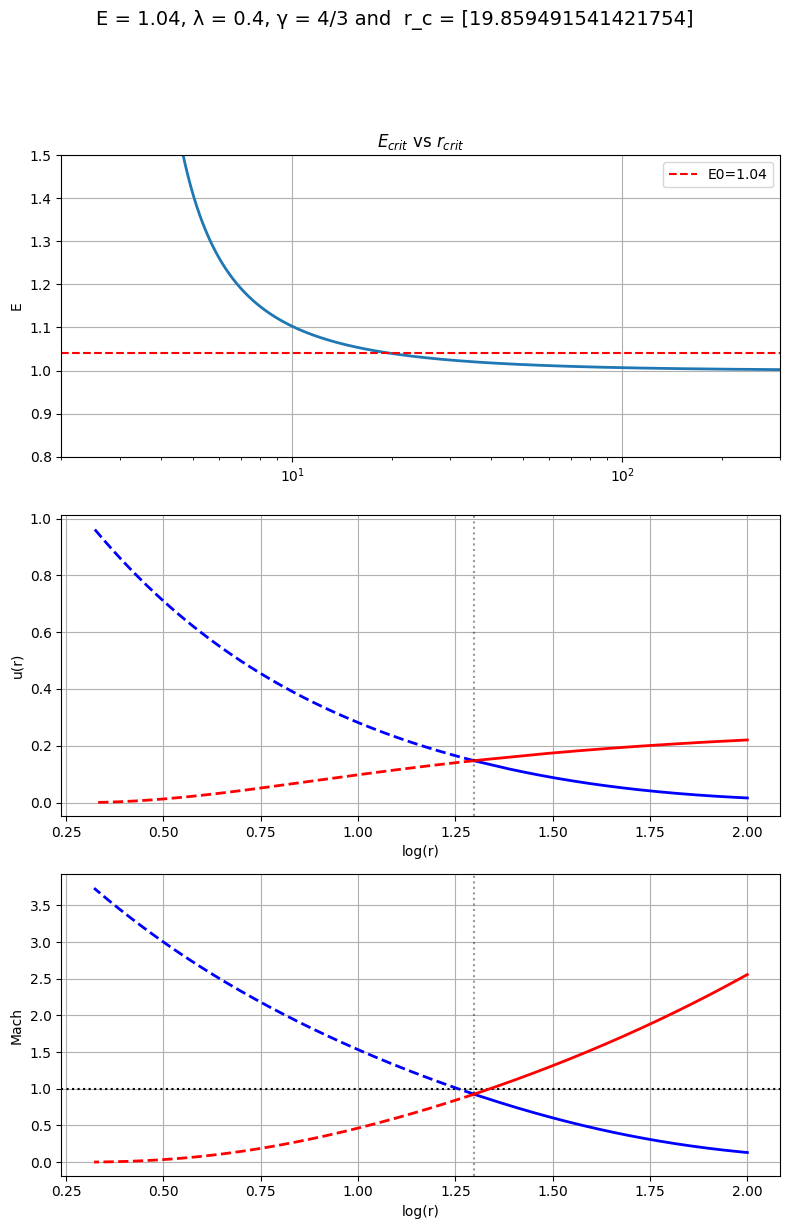

In [6]:
E0 = 1.04
lam0 = 0.4
gamma0 = 4/3


# =======================  ENERGY WORKFLOW  ===========================
# =====================================================================

print("\n================ ENERGY (NUMERIC ONLY) ================")

# Scan r
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list)==0:
    raise RuntimeError("No valid sonic energy values found!")


# ================================================================
# ======================  FIGURE SETUP  ==========================
# ================================================================
fig, (axE, axU, axM) = plt.subplots(3, 1, figsize=(8, 12))

# -------- E vs r_sonic --------
axE.plot(r_list, E_list, lw=2)
axE.axhline(E0, color='r', ls='--', label=f"E0={E0}")
axE.set_xscale('log')  # Set x-axis to logarithmic scale
axE.set_xlim(2, 300)
axE.set_ylim(0.8, 1.5)
axE.set_ylabel("E")
axE.set_title("$E_{crit}$ vs $r_{crit}$")
axE.grid()
axE.legend()

axU.set_ylabel("u(r)")
axU.set_xlabel("log(r)")
axU.grid()

axM.set_ylabel("Mach")
axM.set_xlabel("log(r)")
axM.axhline(1, color="k", ls=":")
axM.grid()

# ---------------------------------------------------------------------
# Plot F(r) = E(r) - E0
# ---------------------------------------------------------------------
F_list = E_list - E0


# ---------------------------------------------------------------------
# Invert: find ALL r_sonic for desired E0 using F(r) and Newton-Raphson
# ---------------------------------------------------------------------
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

# find zero-crossings of F_list to get initial guesses
root_guesses = []
for i in range(len(F_list)-1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i+1]):
        if F_list[i] == 0.0:
            root_guesses.append(r_list[i])
        elif F_list[i]*F_list[i+1] < 0:
            root_guesses.append(0.5*(r_list[i] + r_list[i+1]))

# also include near-zero points as extra guesses (optional)
tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

# refine each guess with Newton-Raphson
roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

# de-duplicate roots
roots_raw = sorted(roots_raw)
unique_roots = []
tol_merge = 1e-4
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > tol_merge:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ======================   RK4 INTEGRATION   =====================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num/den):
        return np.nan
    return num/den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)
    k2c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)

    k3u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)
    k3c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new  = uval  + (k1u + 2*k2u + 2*k3u + k4u)/6.0
    cs_new = csval + (k1c + 2*k2c + 2*k3c + k4c)/6.0
    return u_new, cs_new


# ================================================================
# ===================  PER-SONIC-POINT PLOTS  ====================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    # sound speed at sonic point
    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    # velocity at sonic point 
    u0 = u_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(u0):
        continue
    a_val = a_num(cs0, u0, lam0, r0, gamma0)
    b_val = b_num(cs0, u0, lam0, r0, gamma0)
    c_val = c_num(cs0, u0, lam0, r0, gamma0)
    print("a,b,c =",a_val,b_val,c_val)
    
    # coefficients at sonic point for the quadratic in du/dr
    #a_num = float(a.subs({r: r0, lam: lam0, gamma: gamma0, u: u0, cs: cs0}).evalf())
    #b_num = float(b.subs({r: r0, lam: lam0, gamma: gamma0, u: u0, cs: cs0}).evalf())
    #c_num = float(c.subs({r: r0, lam: lam0, gamma: gamma0, u: u0, cs: cs0}).evalf())

    
    r1 = (-b_val + (b_val**2 - 4*a_val*c_val)**0.5)/(2*a_val)
    r2 = (-b_val - (b_val**2 - 4*a_val*c_val)**0.5)/(2*a_val)
    print("ROOTS:",r1,r2)
    v_real = [r1, r2]

    print("-------------------------------------------------------------------------------------------------------------------------")
    print(f"Sonic point {j}: r = {r0}  |  u_sonic = {u0}  |  cs_sonic = {cs0}\n")

    cnt = 1

    for v0 in v_real:

        print(f"du/dr_critical {cnt}: {v0}\n")
        cnt += 1

        # dcs/dr at sonic point from regularity condition
        s0 = float(s_func(r0, u0, cs0, gamma0, lam0, v0))

        branch = "Wind" if v0 > 0 else "Accretion"
        color  = "red" if branch == "Wind" else "blue"

        # ---------------- OUTWARD INTEGRATION ----------------
        R      = r0
        u_cur  = u0
        cs_cur = cs0

        h = 1e-2
        Rout, Uout, CSout = [R], [u_cur], [cs_cur]

        # small initial step using analytic slopes
        R      += h
        u_cur  += h * v0
        cs_cur += h * s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rout.append(R); Uout.append(u_cur); CSout.append(cs_cur)

            while (R < 100.0 and R > 2.1):
                if R >= 500.0:   # outer cutoff
                    break

                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h

                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break

                Rout.append(R); Uout.append(u_next); CSout.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ---------------- INWARD INTEGRATION ----------------
        R      = r0
        u_cur  = u0
        cs_cur = cs0

        h = -1e-2
        Rin, Uin, CSin = [R], [u_cur], [cs_cur]

        R      += h
        u_cur  += h * v0
        cs_cur += h * s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rin.append(R); Uin.append(u_cur); CSin.append(cs_cur)

            while (R < 100.0 and R > 2.1):
                if R <= 2.1:  # inner cutoff near horizon
                    break

                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h

                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break

                Rin.append(R); Uin.append(u_next); CSin.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ================== PLOT ==================
        log_Rout = np.log10(Rout)
        log_Rin  = np.log10(Rin)

        axU.plot(log_Rout, Uout, color=color, lw=2)
        axU.plot(log_Rin, Uin, color=color, lw=2, ls="--")

        axM.plot(log_Rout, np.array(Uout) / np.array(CSout), color=color, lw=2)
        axM.plot(log_Rin, np.array(Uin) / np.array(CSin), color=color, lw=2, ls="--")

    axU.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)
    axM.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3 and  r_c = {unique_roots}"
plt.suptitle(global_title, fontsize=14, y=1.02)

# ================================================================
# ========================  SAVE FIGURE  =========================
# ================================================================
# Adjust layout after setting the title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the title
plt.savefig("O-type_wedge_Schw.png")
plt.show()


# I-type solution(only inner sonic point exists)


================ ENERGY (NUMERIC ONLY) ================

Sonic radii found: [7.960785141485762]
a,b,c = -0.1286924518877638 -0.010096735052701917 0.009147231645442788
ROOTS: -0.3087037162844225 0.23024740509759736
-------------------------------------------------------------------------------------------------------------------------
Sonic point 1: r = 7.960785141485762  |  u_sonic = 0.24951489671687854  |  cs_sonic = 0.2695068910020181

du/dr_critical 1: -0.3087037162844225

du/dr_critical 2: 0.23024740509759736



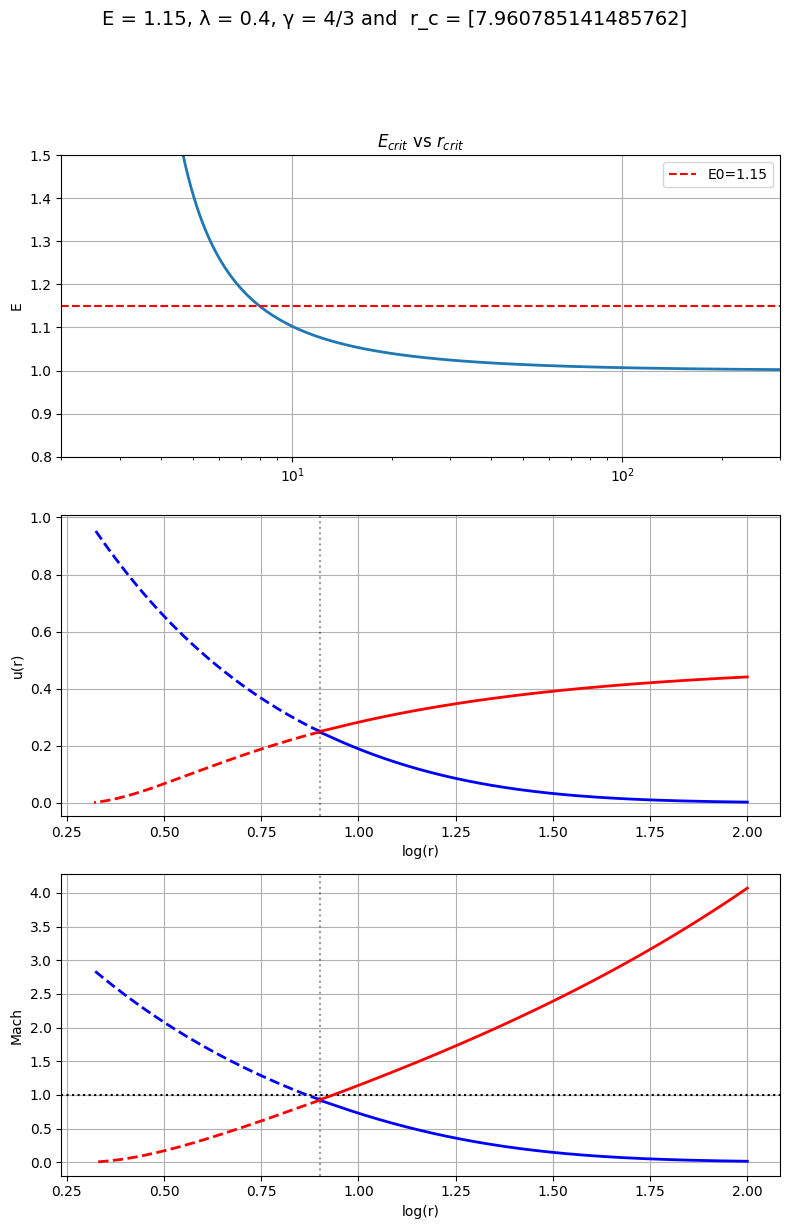

In [7]:
E0 = 1.15
lam0 = 0.4
gamma0 = 4/3


# =======================  ENERGY WORKFLOW  ===========================
# =====================================================================

print("\n================ ENERGY (NUMERIC ONLY) ================")

# Scan r
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list)==0:
    raise RuntimeError("No valid sonic energy values found!")


# ================================================================
# ======================  FIGURE SETUP  ==========================
# ================================================================
fig, (axE, axU, axM) = plt.subplots(3, 1, figsize=(8, 12))

# -------- E vs r_sonic --------
axE.plot(r_list, E_list, lw=2)
axE.axhline(E0, color='r', ls='--', label=f"E0={E0}")
axE.set_xscale('log')  # Set x-axis to logarithmic scale
axE.set_xlim(2, 300)
axE.set_ylim(0.8, 1.5)
axE.set_ylabel("E")
axE.set_title("$E_{crit}$ vs $r_{crit}$")
axE.grid()
axE.legend()

axU.set_ylabel("u(r)")
axU.set_xlabel("log(r)")
axU.grid()

axM.set_ylabel("Mach")
axM.set_xlabel("log(r)")
axM.axhline(1, color="k", ls=":")
axM.grid()

# ---------------------------------------------------------------------
# Plot F(r) = E(r) - E0
# ---------------------------------------------------------------------
F_list = E_list - E0


# ---------------------------------------------------------------------
# Invert: find ALL r_sonic for desired E0 using F(r) and Newton-Raphson
# ---------------------------------------------------------------------
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

# find zero-crossings of F_list to get initial guesses
root_guesses = []
for i in range(len(F_list)-1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i+1]):
        if F_list[i] == 0.0:
            root_guesses.append(r_list[i])
        elif F_list[i]*F_list[i+1] < 0:
            root_guesses.append(0.5*(r_list[i] + r_list[i+1]))

# also include near-zero points as extra guesses (optional)
tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

# refine each guess with Newton-Raphson
roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

# de-duplicate roots
roots_raw = sorted(roots_raw)
unique_roots = []
tol_merge = 1e-4
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > tol_merge:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ======================   RK4 INTEGRATION   =====================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num/den):
        return np.nan
    return num/den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)
    k2c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k1u, csval + 0.5*k1c)

    k3u = h * du_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)
    k3c = h * dcs_dr_numeric(R + 0.5*h, uval + 0.5*k2u, csval + 0.5*k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new  = uval  + (k1u + 2*k2u + 2*k3u + k4u)/6.0
    cs_new = csval + (k1c + 2*k2c + 2*k3c + k4c)/6.0
    return u_new, cs_new


# ================================================================
# ===================  PER-SONIC-POINT PLOTS  ====================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    # sound speed at sonic point
    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    # velocity at sonic point 
    u0 = u_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(u0):
        continue
    a_val = a_num(cs0, u0, lam0, r0, gamma0)
    b_val = b_num(cs0, u0, lam0, r0, gamma0)
    c_val = c_num(cs0, u0, lam0, r0, gamma0)
    print("a,b,c =",a_val,b_val,c_val)
    
    # coefficients at sonic point for the quadratic in du/dr
    #a_num = float(a.subs({r: r0, lam: lam0, gamma: gamma0, u: u0, cs: cs0}).evalf())
    #b_num = float(b.subs({r: r0, lam: lam0, gamma: gamma0, u: u0, cs: cs0}).evalf())
    #c_num = float(c.subs({r: r0, lam: lam0, gamma: gamma0, u: u0, cs: cs0}).evalf())

    
    r1 = (-b_val + (b_val**2 - 4*a_val*c_val)**0.5)/(2*a_val)
    r2 = (-b_val - (b_val**2 - 4*a_val*c_val)**0.5)/(2*a_val)
    print("ROOTS:",r1,r2)
    v_real = [r1, r2]

    print("-------------------------------------------------------------------------------------------------------------------------")
    print(f"Sonic point {j}: r = {r0}  |  u_sonic = {u0}  |  cs_sonic = {cs0}\n")

    cnt = 1

    for v0 in v_real:

        print(f"du/dr_critical {cnt}: {v0}\n")
        cnt += 1

        # dcs/dr at sonic point from regularity condition
        s0 = float(s_func(r0, u0, cs0, gamma0, lam0, v0))

        branch = "Wind" if v0 > 0 else "Accretion"
        color  = "red" if branch == "Wind" else "blue"

        # ---------------- OUTWARD INTEGRATION ----------------
        R      = r0
        u_cur  = u0
        cs_cur = cs0

        h = 1e-2
        Rout, Uout, CSout = [R], [u_cur], [cs_cur]

        # small initial step using analytic slopes
        R      += h
        u_cur  += h * v0
        cs_cur += h * s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rout.append(R); Uout.append(u_cur); CSout.append(cs_cur)

            while (R < 100.0 and R > 2.1):
                if R >= 500.0:   # outer cutoff
                    break

                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h

                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break

                Rout.append(R); Uout.append(u_next); CSout.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ---------------- INWARD INTEGRATION ----------------
        R      = r0
        u_cur  = u0
        cs_cur = cs0

        h = -1e-2
        Rin, Uin, CSin = [R], [u_cur], [cs_cur]

        R      += h
        u_cur  += h * v0
        cs_cur += h * s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rin.append(R); Uin.append(u_cur); CSin.append(cs_cur)

            while (R < 100.0 and R > 2.1):
                if R <= 2.1:  # inner cutoff near horizon
                    break

                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h

                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break

                Rin.append(R); Uin.append(u_next); CSin.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        # ================== PLOT ==================
        log_Rout = np.log10(Rout)
        log_Rin  = np.log10(Rin)

        axU.plot(log_Rout, Uout, color=color, lw=2)
        axU.plot(log_Rin, Uin, color=color, lw=2, ls="--")

        axM.plot(log_Rout, np.array(Uout) / np.array(CSout), color=color, lw=2)
        axM.plot(log_Rin, np.array(Uin) / np.array(CSin), color=color, lw=2, ls="--")

    axU.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)
    axM.axvline(np.log10(r0), color="k", ls=":", alpha=0.4)

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3 and  r_c = {unique_roots}"
plt.suptitle(global_title, fontsize=14, y=1.02)

# ================================================================
# ========================  SAVE FIGURE  =========================
# ================================================================
# Adjust layout after setting the title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the title
plt.savefig("O-type_wedge_Schw.png")
plt.show()


# Type A (Both inner and outer sonic point exist and transonic solution passes though outer while alpha-solution passes though inner)


================ ENERGY (NUMERIC ONLY) ================


Sonic radii found: [5.237990273267643, 12.76678766025113, 616.7671108223535]


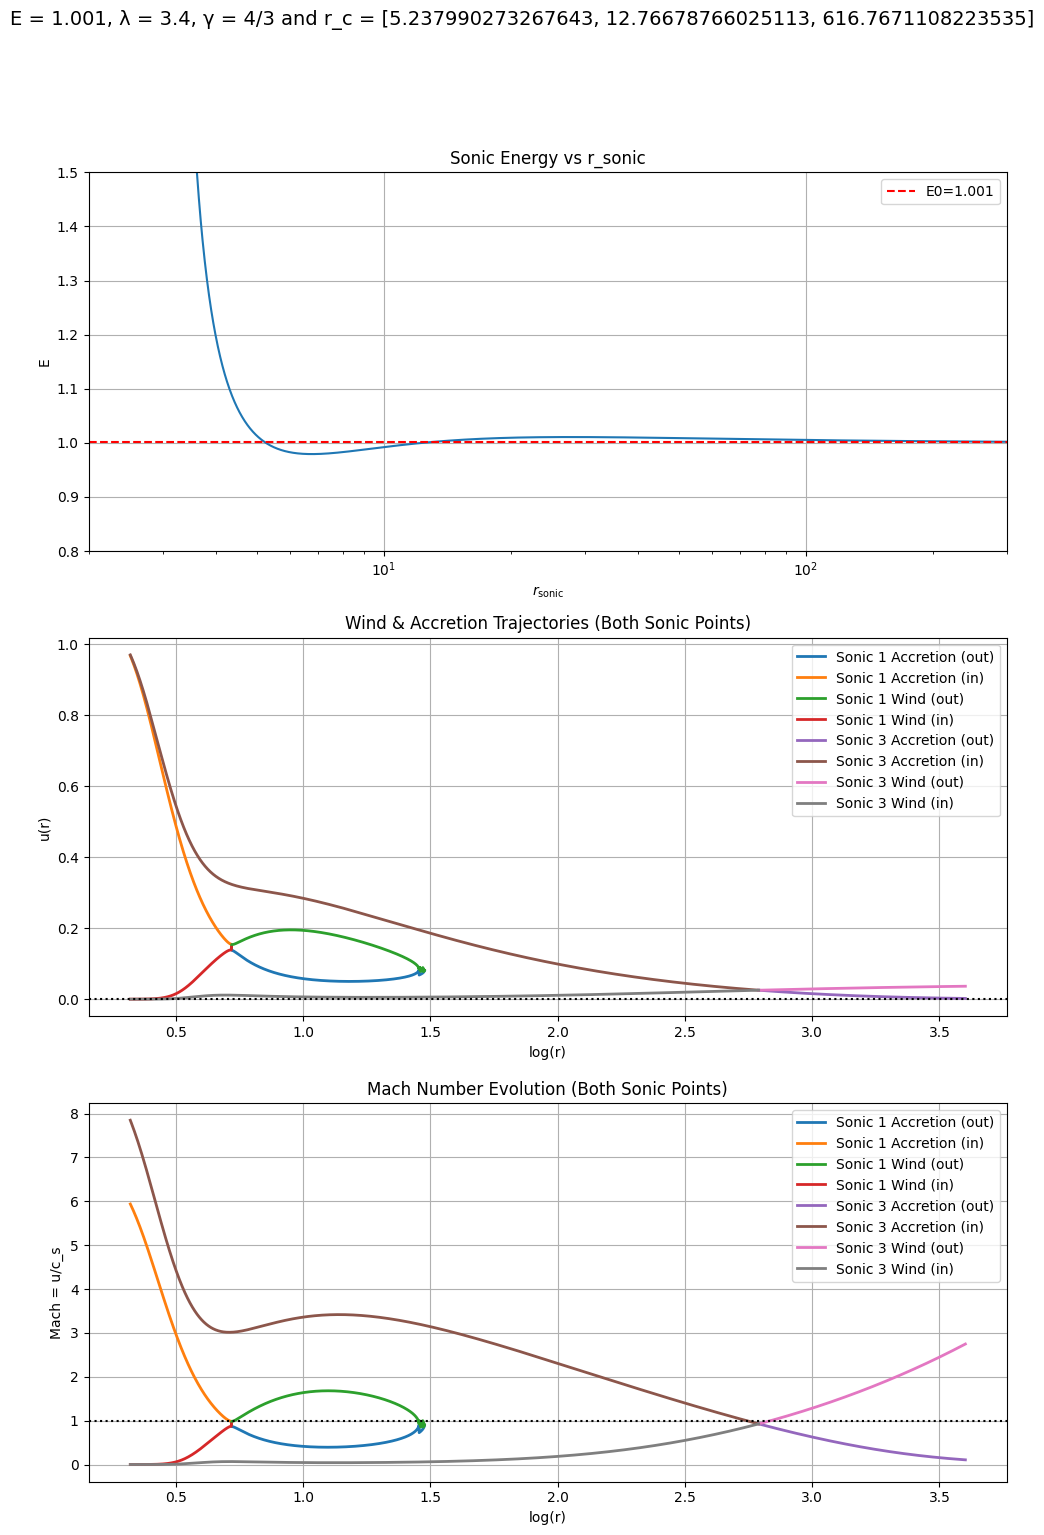

In [8]:
import numpy as np
import matplotlib.pyplot as plt

E0 = 1.001
lam0 = 3.4
gamma0 = 4/3

print("\n================ ENERGY (NUMERIC ONLY) ================\n")

# ================================================================
# ======================= ENERGY SCAN ============================
# ================================================================
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list) == 0:
    raise RuntimeError("No valid sonic energy values found!")

# ================================================================
# =================== FIND SONIC RADII ===========================
# ================================================================
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

F_list = E_list - E0
root_guesses = []
for i in range(len(F_list) - 1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i + 1]):
        if F_list[i] == 0.0:
            root_guesses.append(r_list[i])
        elif F_list[i] * F_list[i + 1] < 0:
            root_guesses.append(0.5 * (r_list[i] + r_list[i + 1]))

tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

roots_raw = sorted(roots_raw)
unique_roots = []
tol_merge = 1e-4
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > tol_merge:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ================== NUMERICAL ODE HELPERS =======================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num / den):
        return np.nan
    return num / den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)
    k2c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)

    k3u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)
    k3c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new = uval + (k1u + 2 * k2u + 2 * k3u + k4u) / 6.0
    cs_new = csval + (k1c + 2 * k2c + 2 * k3c + k4c) / 6.0
    return u_new, cs_new

# ================================================================
# ============ STORAGE FOR GLOBAL PLOTS (U + MACH) ===============
# ================================================================
global_u_curves = []
global_cs_curves = []
global_r_curves = []
labels = []

# ================================================================
# =================== MAIN SONIC LOOP ============================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    # if you still want to skip second sonic:
    if j == 2:
        continue

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    u0 = u_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(u0):
        continue

    a_val = a_num(cs0, u0, lam0, r0, gamma0)
    b_val = b_num(cs0, u0, lam0, r0, gamma0)
    c_val = c_num(cs0, u0, lam0, r0, gamma0)

    disc = b_val**2 - 4*a_val*c_val
    if disc < 0:
        continue

    v_real = [
        (-b_val + np.sqrt(disc))/(2*a_val),
        (-b_val - np.sqrt(disc))/(2*a_val)
    ]

    for v0 in v_real:

        s0 = float(s_func(r0, u0, cs0, gamma0, lam0, v0))
        branch = "Wind" if v0 > 0 else "Accretion"

        # ================= OUTWARD =================
        R = r0; u_cur=u0; cs_cur=cs0
        h = 1e-2
        Rout=[R]; Uout=[u_cur]; CSout=[cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rout.append(R); Uout.append(u_cur); CSout.append(cs_cur)

            while (R < 4000.0 and R > 2.1):
                if(R > 30.0 and j == 1):
                    break
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break
                Rout.append(R); Uout.append(u_next); CSout.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        global_r_curves.append(np.array(Rout))
        global_u_curves.append(np.array(Uout))
        global_cs_curves.append(np.array(CSout))
        labels.append(f"Sonic {j} {branch} (out)")

        # ================= INWARD =================
        R = r0; u_cur=u0; cs_cur=cs0
        h = -1e-2
        Rin=[R]; Uin=[u_cur]; CSin=[cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rin.append(R); Uin.append(u_cur); CSin.append(cs_cur)

            while (R < 2000.0 and R > 2.1):
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break
                Rin.append(R); Uin.append(u_next); CSin.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        global_r_curves.append(np.array(Rin))
        global_u_curves.append(np.array(Uin))
        global_cs_curves.append(np.array(CSin))
        labels.append(f"Sonic {j} {branch} (in)")

# ================================================================
# =================== PLOT ALL IN SUBPLOTS =======================
# ================================================================
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: E vs r_sonic
axs[0].plot(r_list, E_list)
axs[0].axhline(E0, color='r', linestyle='--', label=f"E0={E0}")
axs[0].set_xscale('log')
axs[0].set_xlabel(r"$r_{\rm sonic}$")
axs[0].set_xlim(2.0, 300.0)
axs[0].set_ylim(0.8, 1.5)
axs[0].set_ylabel("E")
axs[0].set_title("Sonic Energy vs r_sonic")
axs[0].grid()
axs[0].legend()

# Plot 2: u(r)
for r, u, lbl in zip(global_r_curves, global_u_curves, labels):
    axs[1].plot(np.log10(r), u, lw=2, label=lbl)
axs[1].axhline(0, color='k', ls=':')
axs[1].set_xlabel("log(r)")
axs[1].set_ylabel("u(r)")
axs[1].set_title("Wind & Accretion Trajectories (Both Sonic Points)")
axs[1].grid()
axs[1].legend()

# Plot 3: Mach(r)
for r, u, cs, lbl in zip(global_r_curves, global_u_curves, global_cs_curves, labels):
    axs[2].plot(np.log10(r), u / cs, lw=2, label=lbl)
axs[2].axhline(1.0, color='k', ls=':')
axs[2].set_xlabel("log(r)")
axs[2].set_ylabel("Mach = u/c_s")
axs[2].set_title("Mach Number Evolution (Both Sonic Points)")
axs[2].grid()
axs[2].legend()

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3 and r_c = {unique_roots}"
fig.suptitle(global_title, fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make space for the title
plt.show()

# Type W (Both inner and outer sonic point exist and transonic solution passes though inner while alpha-solution passes though outer)


================ ENERGY (NUMERIC ONLY) ================


Sonic radii found: [4.592892319753715, 19.03195172530047, 104.45002254272636]


/tmp/ipykernel_72081/1529399066.py:240: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make space for the title


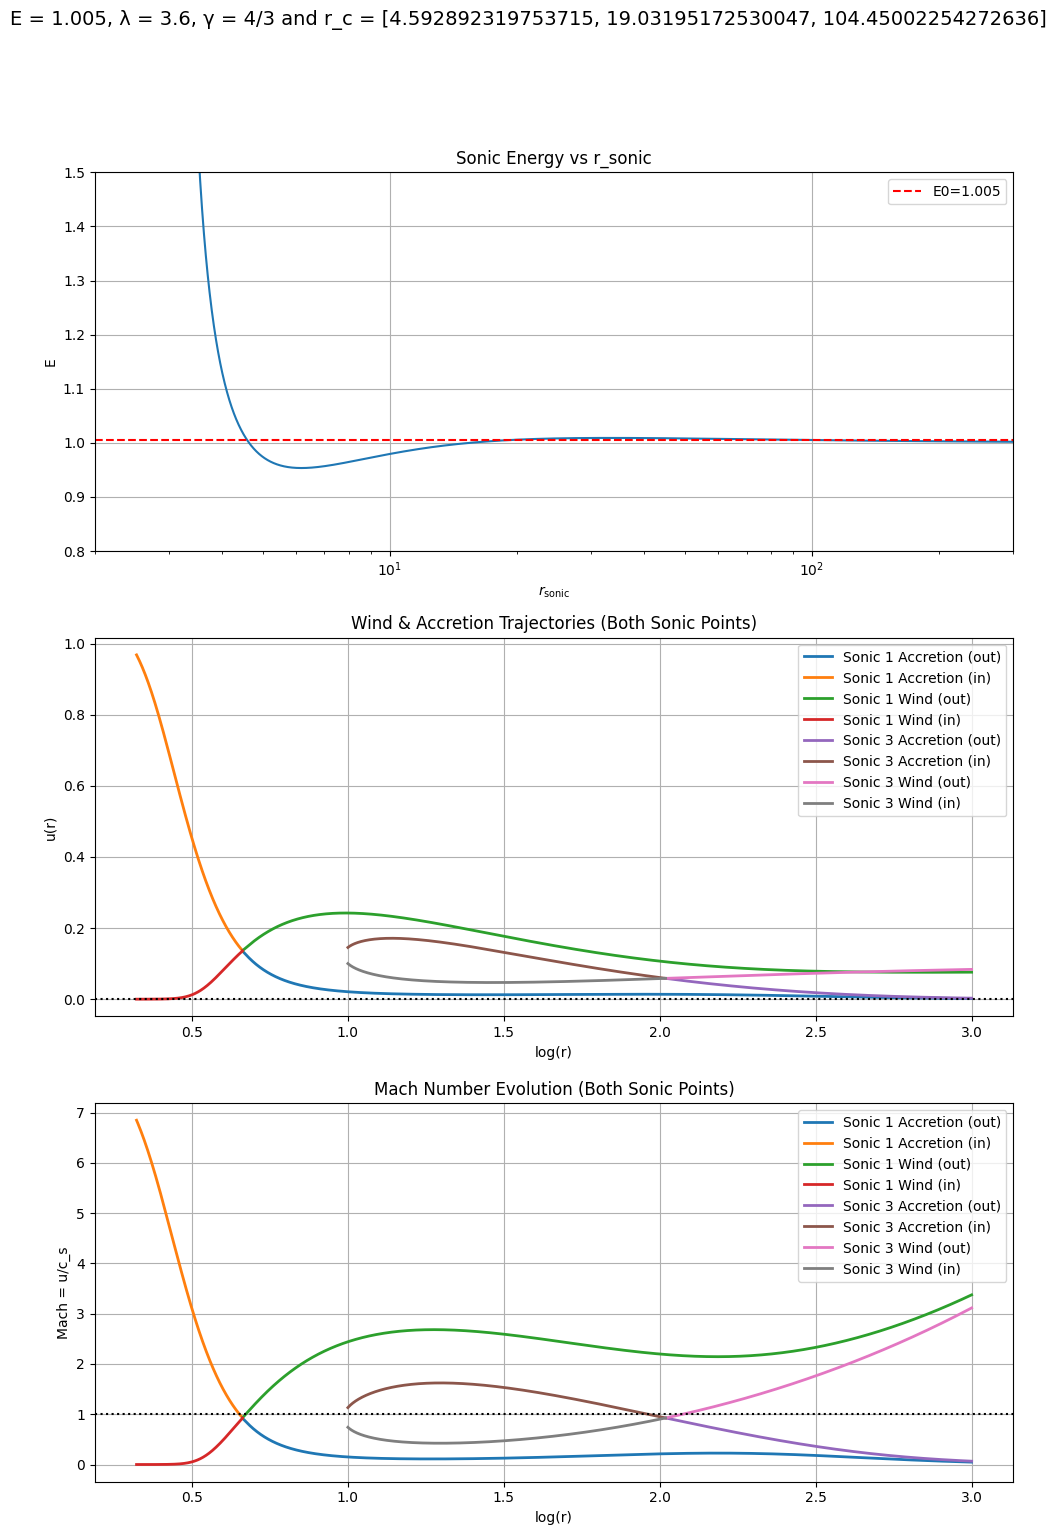

In [9]:
import numpy as np
import matplotlib.pyplot as plt

E0 = 1.005
lam0 = 3.6
gamma0 = 4/3

print("\n================ ENERGY (NUMERIC ONLY) ================\n")

# ================================================================
# ======================= ENERGY SCAN ============================
# ================================================================
r_scan = np.linspace(2.4, 1500, 200000)

E_list = []
r_list = []

for R in r_scan:
    val = E_sonic_numeric(R, lam0, gamma0)
    if np.isfinite(val) and val > 0:
        r_list.append(R)
        E_list.append(val)

r_list = np.array(r_list)
E_list = np.array(E_list)

if len(r_list) == 0:
    raise RuntimeError("No valid sonic energy values found!")

# ================================================================
# =================== FIND SONIC RADII ===========================
# ================================================================
def F_num(R):
    return E_sonic_numeric(R, lam0, gamma0) - E0

F_list = E_list - E0
root_guesses = []
for i in range(len(F_list) - 1):
    if np.isfinite(F_list[i]) and np.isfinite(F_list[i + 1]):
        if F_list[i] == 0.0:
            root_guesses.append(r_list[i])
        elif F_list[i] * F_list[i + 1] < 0:
            root_guesses.append(0.5 * (r_list[i] + r_list[i + 1]))

tol_near = 1e-3
for i, val in enumerate(F_list):
    if np.isfinite(val) and abs(val) < tol_near:
        root_guesses.append(r_list[i])

roots_raw = []
for g in root_guesses:
    r_root = newton_root(F_num, g)
    if np.isfinite(r_root) and 2.0 < r_root < 1200.0:
        roots_raw.append(r_root)

roots_raw = sorted(roots_raw)
unique_roots = []
tol_merge = 1e-4
for rr in roots_raw:
    if not unique_roots or abs(rr - unique_roots[-1]) > tol_merge:
        unique_roots.append(rr)

if not unique_roots:
    raise RuntimeError("No sonic radii found for this E0.")

print("\nSonic radii found:", unique_roots)

# ================================================================
# ================== NUMERICAL ODE HELPERS =======================
# ================================================================
def du_dr_numeric(R, uval, csval):
    num = Num_func(R, uval, csval, gamma0, lam0)
    den = Denom_func(R, uval, csval, gamma0, lam0)
    if den == 0 or not np.isfinite(num / den):
        return np.nan
    return num / den

def dcs_dr_numeric(R, uval, csval):
    v_now = du_dr_numeric(R, uval, csval)
    if not np.isfinite(v_now):
        return np.nan
    return s_func(R, uval, csval, gamma0, lam0, v_now)

def rk4_step(R, uval, csval, h):
    k1u = h * du_dr_numeric(R, uval, csval)
    k1c = h * dcs_dr_numeric(R, uval, csval)

    k2u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)
    k2c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k1u, csval + 0.5 * k1c)

    k3u = h * du_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)
    k3c = h * dcs_dr_numeric(R + 0.5 * h, uval + 0.5 * k2u, csval + 0.5 * k2c)

    k4u = h * du_dr_numeric(R + h, uval + k3u, csval + k3c)
    k4c = h * dcs_dr_numeric(R + h, uval + k3u, csval + k3c)

    u_new = uval + (k1u + 2 * k2u + 2 * k3u + k4u) / 6.0
    cs_new = csval + (k1c + 2 * k2c + 2 * k3c + k4c) / 6.0
    return u_new, cs_new

# ================================================================
# ============ STORAGE FOR GLOBAL PLOTS (U + MACH) ===============
# ================================================================
global_u_curves = []
global_cs_curves = []
global_r_curves = []
labels = []

# ================================================================
# =================== MAIN SONIC LOOP ============================
# ================================================================
for j, r0 in enumerate(unique_roots, start=1):

    # if you still want to skip second sonic:
    if j == 2:
        continue

    cs0 = cs_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(cs0):
        continue

    u0 = u_sonic_numeric(r0, lam0, gamma0)
    if not np.isfinite(u0):
        continue

    a_val = a_num(cs0, u0, lam0, r0, gamma0)
    b_val = b_num(cs0, u0, lam0, r0, gamma0)
    c_val = c_num(cs0, u0, lam0, r0, gamma0)

    disc = b_val**2 - 4*a_val*c_val
    if disc < 0:
        continue

    v_real = [
        (-b_val + np.sqrt(disc))/(2*a_val),
        (-b_val - np.sqrt(disc))/(2*a_val)
    ]

    for v0 in v_real:

        s0 = float(s_func(r0, u0, cs0, gamma0, lam0, v0))
        branch = "Wind" if v0 > 0 else "Accretion"

        # ================= OUTWARD =================
        R = r0; u_cur=u0; cs_cur=cs0
        h = 1e-3
        Rout=[R]; Uout=[u_cur]; CSout=[cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rout.append(R); Uout.append(u_cur); CSout.append(cs_cur)

            while (R < 1000.0 and R > 2.1):
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break
                Rout.append(R); Uout.append(u_next); CSout.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        global_r_curves.append(np.array(Rout))
        global_u_curves.append(np.array(Uout))
        global_cs_curves.append(np.array(CSout))
        labels.append(f"Sonic {j} {branch} (out)")

        # ================= INWARD =================
        R = r0; u_cur=u0; cs_cur=cs0
        h = -1e-3
        Rin=[R]; Uin=[u_cur]; CSin=[cs_cur]

        R += h
        u_cur += h*v0
        cs_cur += h*s0

        if np.isfinite(u_cur) and np.isfinite(cs_cur):
            Rin.append(R); Uin.append(u_cur); CSin.append(cs_cur)

            while (R < 1000.0 and R > 2.1):
                if(j == 3 and R < 10.0):
                    break
                u_next, cs_next = rk4_step(R, u_cur, cs_cur, h)
                R += h
                if (not np.isfinite(u_next) or not np.isfinite(cs_next) or
                    cs_next <= 0 or cs_next >= 1 or
                    u_next  <= 0 or u_next  >= 1):
                    break
                Rin.append(R); Uin.append(u_next); CSin.append(cs_next)
                u_cur, cs_cur = u_next, cs_next

        global_r_curves.append(np.array(Rin))
        global_u_curves.append(np.array(Uin))
        global_cs_curves.append(np.array(CSin))
        labels.append(f"Sonic {j} {branch} (in)")

# ================================================================
# =================== PLOT ALL IN SUBPLOTS =======================
# ================================================================
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: E vs r_sonic
axs[0].plot(r_list, E_list)
axs[0].axhline(E0, color='r', linestyle='--', label=f"E0={E0}")
axs[0].set_xscale('log')
axs[0].set_xlabel(r"$r_{\rm sonic}$")
axs[0].set_xlim(2.0, 300.0)
axs[0].set_ylim(0.8, 1.5)
axs[0].set_ylabel("E")
axs[0].set_title("Sonic Energy vs r_sonic")
axs[0].grid()
axs[0].legend()


# Plot 2: u(r)
for r, u, lbl in zip(global_r_curves, global_u_curves, labels):
    axs[1].plot(np.log10(r), u, lw=2, label=lbl)
axs[1].axhline(0, color='k', ls=':')
axs[1].set_xlabel("log(r)")
axs[1].set_ylabel("u(r)")
axs[1].set_title("Wind & Accretion Trajectories (Both Sonic Points)")
axs[1].grid()
axs[1].legend()

# Plot 3: Mach(r)
for r, u, cs, lbl in zip(global_r_curves, global_u_curves, global_cs_curves, labels):
    axs[2].plot(np.log10(r), u / cs, lw=2, label=lbl)
axs[2].axhline(1.0, color='k', ls=':')
axs[2].set_xlabel("log(r)")
axs[2].set_ylabel("Mach = u/c_s")
axs[2].set_title("Mach Number Evolution (Both Sonic Points)")
axs[2].grid()
axs[2].legend()

global_title = f"E = {E0}, λ = {lam0}, γ = 4/3 and r_c = {unique_roots}"
fig.suptitle(global_title, fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make space for the title
plt.show()

# E_c vs r_c plot for varying $\lambda$

/tmp/ipykernel_266288/973002765.py:14: RuntimeWarning: invalid value encountered in sqrt
  return factor * np.sqrt((1-2/r)/((1-u2)*(1-(1-2/r)*lam**2/r**2)))


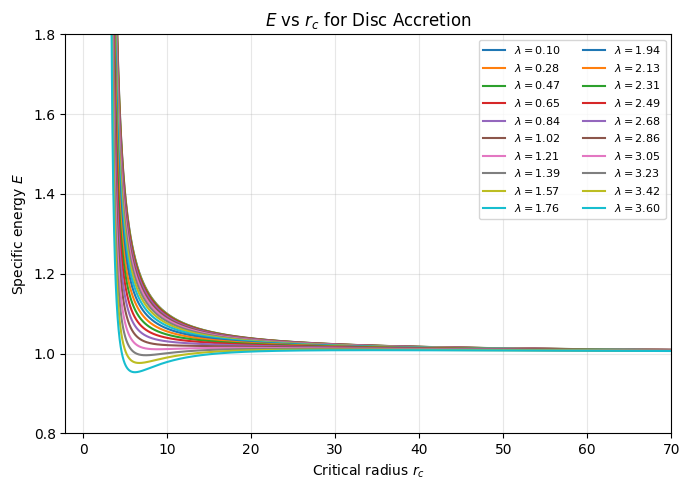

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def Ec_computed_given_rc(r, lam, gamma):
    f = -(lam**2/r**3)*(1-(3/r))/(1 - (1-(2/r))*(lam/r)**2)  + 1/(r**2 - 2*r)
    A = (1/r) + 1/(r**2 - 2*r) + 0.5*(3*r**2 - lam**2)/(r**3 - (lam**2)*(r-2))
    if(f < 0):
        print("Error : f < 0 for r = ",r,"lam = ",lam)
    if(A < 0):
        print("Error : A < 0 for r = ",r,"lam = ",lam)
    u2 = f/A
    cs2 = f*(gamma+1)/(2*A)
    factor = (gamma - 1)/(gamma - 1 - cs2)
    return factor * np.sqrt((1-2/r)/((1-u2)*(1-(1-2/r)*lam**2/r**2)))
    
def plot_Ec_vs_rc():
    gamma = 4.0 / 3.0

    plt.figure(figsize=(7,5))

    rc_vals = np.linspace(2.1, 1000.0, 50000)
    lam_vals = np.linspace(0.1, 3.6, 20)

    
    for lam in lam_vals:

        r_list = []
        E_list = []

        for r in rc_vals:
            E = Ec_computed_given_rc(r, lam, gamma)

            # keep only physical values
            if np.isfinite(E) and E > 0.0:
                r_list.append(r)
                E_list.append(E)

        if len(r_list) > 0:
            plt.plot(
                r_list,
                E_list,
                lw=1.5,
                label=rf"$\lambda={lam:.2f}$"
            )

    plt.xlabel(r"Critical radius $r_c$")
    plt.ylabel(r"Specific energy $E$")
    plt.ylim(0.8,1.8)
    plt.xlim(-2.1,70.0)
    plt.title(r"$E$ vs $r_c$ for Disc Accretion")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


plot_Ec_vs_rc()


/tmp/ipykernel_37941/1465182589.py:14: RuntimeWarning: invalid value encountered in sqrt
  return factor * np.sqrt((1-2/r)/((1-u2)*(1-(1-2/r)*lam**2/r**2)))


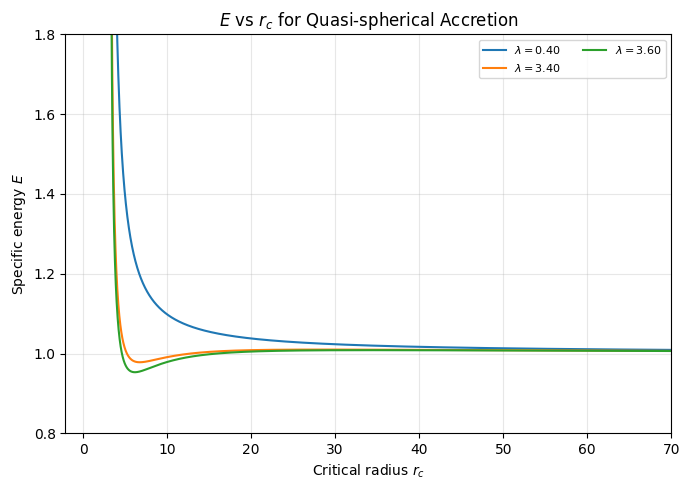

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def Ec_computed_given_rc(r, lam, gamma):
    f = -(lam**2/r**3)*(1-(3/r))/(1 - (1-(2/r))*(lam/r)**2)  + 1/(r**2 - 2*r)
    A = (1/r) + 1/(r**2 - 2*r) + 0.5*(3*r**2 - lam**2)/(r**3 - (lam**2)*(r-2))
    if(f < 0):
        print("Error : f < 0 for r = ",r,"lam = ",lam)
    if(A < 0):
        print("Error : A < 0 for r = ",r,"lam = ",lam)
    u2 = f/A
    cs2 = f*(gamma+1)/(2*A)
    factor = (gamma - 1)/(gamma - 1 - cs2)
    return factor * np.sqrt((1-2/r)/((1-u2)*(1-(1-2/r)*lam**2/r**2)))
    
def plot_Ec_vs_rc():
    gamma = 4.0 / 3.0

    plt.figure(figsize=(7,5))

    rc_vals = np.linspace(2.1, 1000.0, 50000)
    lam_vals = np.array([0.4,3.4,3.6])

    
    for lam in lam_vals:

        r_list = []
        E_list = []

        for r in rc_vals:
            E = Ec_computed_given_rc(r, lam, gamma)

            # keep only physical values
            if np.isfinite(E) and E > 0.0:
                r_list.append(r)
                E_list.append(E)

        if len(r_list) > 0:
            plt.plot(
                r_list,
                E_list,
                lw=1.5,
                label=rf"$\lambda={lam:.2f}$"
            )

    plt.xlabel(r"Critical radius $r_c$")
    plt.ylabel(r"Specific energy $E$")
    plt.ylim(0.8,1.8)
    plt.xlim(-2.1,70.0)
    plt.title(r"$E$ vs $r_c$ for Quasi-spherical Accretion")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


plot_Ec_vs_rc()


/tmp/ipykernel_72081/3792993929.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")
/tmp/ipykernel_72081/3792993929.py:15: RuntimeWarning: invalid value encountered in sqrt
  return factor * np.sqrt((1-2/r)/((1-u2)*(1-(1-2/r)*lam**2/r**2)))
/tmp/ipykernel_72081/3792993929.py:55: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(-2.1,70.0)


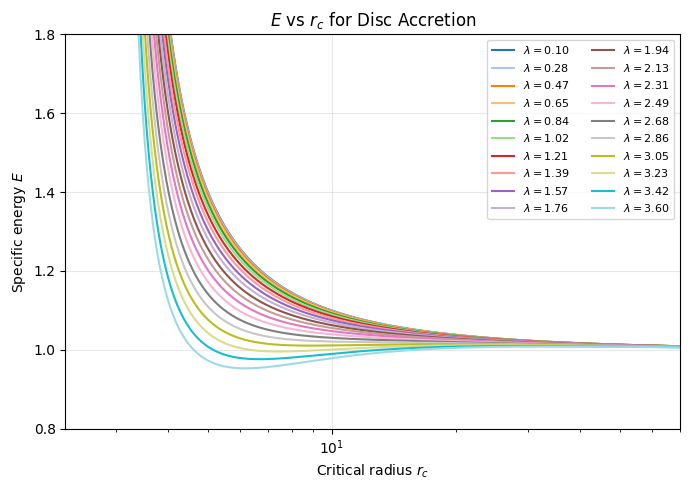

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

def Ec_computed_given_rc(r, lam, gamma):
    f = -(lam**2/r**3)*(1-(3/r))/(1 - (1-(2/r))*(lam/r)**2)  + 1/(r**2 - 2*r)
    A = (1/r) + 1/(r**2 - 2*r) + 0.5*(3*r**2 - lam**2)/(r**3 - (lam**2)*(r-2))
    if(f < 0):
        print("Error : f < 0 for r = ",r,"lam = ",lam)
    if(A < 0):
        print("Error : A < 0 for r = ",r,"lam = ",lam)
    u2 = f/A
    cs2 = f*(gamma+1)/(2*A)
    factor = (gamma - 1)/(gamma - 1 - cs2)
    return factor * np.sqrt((1-2/r)/((1-u2)*(1-(1-2/r)*lam**2/r**2)))
    
def plot_Ec_vs_rc():
    gamma = 4.0 / 3.0

    plt.figure(figsize=(7,5))

    rc_vals = np.linspace(2.1, 1000.0, 50000)
    lam_vals = np.linspace(0.1, 3.6, 20)

    # Use the tab20 colormap for consistent colors
    cmap = get_cmap("tab20")
    colors = cmap(np.linspace(0, 1, len(lam_vals)))
    
    for lam, color in zip(lam_vals, colors):

        r_list = []
        E_list = []

        for r in rc_vals:
            E = Ec_computed_given_rc(r, lam, gamma)

            # keep only physical values
            if np.isfinite(E) and E > 0.0:
                r_list.append(r)
                E_list.append(E)

        if len(r_list) > 0:
            plt.plot(
                r_list,
                E_list,
                lw=1.5,
                label=rf"$\lambda={lam:.2f}$",
                color=color
            )

    plt.xlabel(r"Critical radius $r_c$")
    plt.ylabel(r"Specific energy $E$")
    plt.xscale('log')
    plt.ylim(0.8,1.8)
    plt.xlim(-2.1,70.0)
    plt.title(r"$E$ vs $r_c$ for Disc Accretion")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig("Hydro-EvsRc.png")
    plt.show()

plot_Ec_vs_rc()

In [ ]:
1